<a href="https://colab.research.google.com/github/JampaniDivyaSree/Machine_Learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import csv
a=[]
with open("/content/sport.csv","r") as csvfile:
  reader=csv.reader(csvfile)
  for row in reader:
    a.append(row)
    print(a)
  print("\nTotal number of instances are:",len(a));
  num_attr=len(a[0])-1
  print("\nInitial hypothesis")
  hypothesis=["0"]*num_attr
  print(hypothesis)
  for i in range(0,len(a)):
    if a[i][num_attr]=="yes":
      for j in range(0,num_attr):
        if hypothesis[j]=="0" or hypothesis[j]==a[i][j]:
          hypothesis[j]=a[i][j]
        else:
          hypothesis[j]="?"
    print("\n hypothesis for instance{} is:".format(i+1),hypothesis)
  print("\nmaximal hypothesis is",hypothesis)

[['sunny', 'warm', 'normal', 'strong', 'warm', 'warm', 'yes']]
[['sunny', 'warm', 'normal', 'strong', 'warm', 'warm', 'yes'], ['sunny', 'warm', 'high', 'strong', 'warm', 'warm', 'yes']]
[['sunny', 'warm', 'normal', 'strong', 'warm', 'warm', 'yes'], ['sunny', 'warm', 'high', 'strong', 'warm', 'warm', 'yes'], ['rainy', 'cold', 'high', 'strong', 'warm', 'change', 'no']]
[['sunny', 'warm', 'normal', 'strong', 'warm', 'warm', 'yes'], ['sunny', 'warm', 'high', 'strong', 'warm', 'warm', 'yes'], ['rainy', 'cold', 'high', 'strong', 'warm', 'change', 'no'], ['sunny', 'warm', 'high', 'strong', 'cool', 'change', 'yes']]

Total number of instances are: 4

Initial hypothesis
['0', '0', '0', '0', '0', '0']

 hypothesis for instance1 is: ['sunny', 'warm', 'normal', 'strong', 'warm', 'warm']

 hypothesis for instance2 is: ['sunny', 'warm', '?', 'strong', 'warm', 'warm']

 hypothesis for instance3 is: ['sunny', 'warm', '?', 'strong', 'warm', 'warm']

 hypothesis for instance4 is: ['sunny', 'warm', '?', 

In [ ]:
import pandas as pd
import numpy as np
data=pd.read_csv("sport.csv")
c=np.array(data.iloc[:,0:-1])
t=np.array(data.iloc[:,-1])
def learn(c,t):
  s_h=c[0].copy()
  g_h=[["?" for i in range(len(s_h))]for i in range(len(s_h))]
  for i,h in enumerate(c):
    if t[i]=="yes":
      for j in range(len(s_h)):
        if h[j]!=s_h[j]:
          g_h[j][j]="?"
          s_h[j]="?"
    if t[i]=="no":
      for j in range(len(s_h)):
        if h[j]!=s_h[j]:
          g_h[j][j]=s_h[j]
        else:
          g_h[j][j]="?"
    print("step{}".format(i+1))
    print(s_h)
    print(g_h)
  return s_h,g_h
s,g=learn(c,t)

step1
['sunny' 'warm' 'high' 'strong' 'warm' 'warm']
[['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]
step2
['sunny' 'warm' 'high' 'strong' 'warm' 'warm']
[['sunny', '?', '?', '?', '?', '?'], ['?', 'warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', 'warm']]
step3
['sunny' 'warm' 'high' 'strong' '?' '?']
[['sunny', '?', '?', '?', '?', '?'], ['?', 'warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]


In [ ]:
print(data)
print(g)

   sunny  warm normal  strong warm.1  warm.2  yes
0  sunny  warm   high  strong   warm    warm  yes
1  rainy  cold   high  strong   warm  change   no
2  sunny  warm   high  strong   cool  change  yes
[['sunny', '?', '?', '?', '?', '?'], ['?', 'warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]


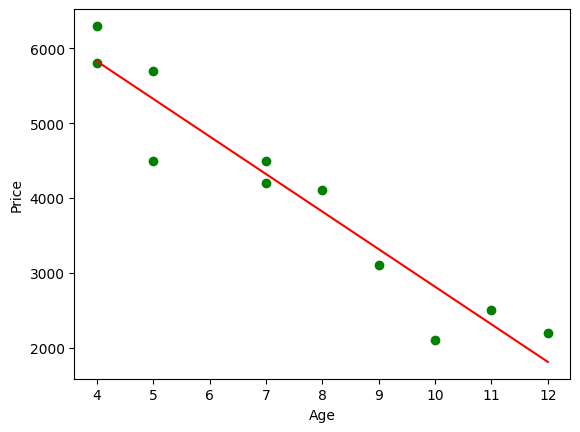

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.read_csv("3.csv")
age=data["Age"]
price=data["Price"]
num=np.size(age)
m_age=np.mean(age)
m_price=np.mean(price)
CD_priceage=np.sum(price*age)-num*m_age*m_price
CD_ageage=np.sum(age*age)-num*m_age*m_age
b1=CD_priceage/CD_ageage
b0=m_price-b1*m_age
plt.scatter(age,price,color="green",marker="o")
response_vector=b0+b1*age
plt.plot(age,response_vector,color="r")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("3-2.csv")
x=data.iloc[:,[2,3]].values
y=data.iloc[:,4].values
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[3]]


<ipython-input-9-d80fdc70a76a>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set==j,0],x_set[y_set==j,1],c=ListedColormap('green','red')(i),label=j)


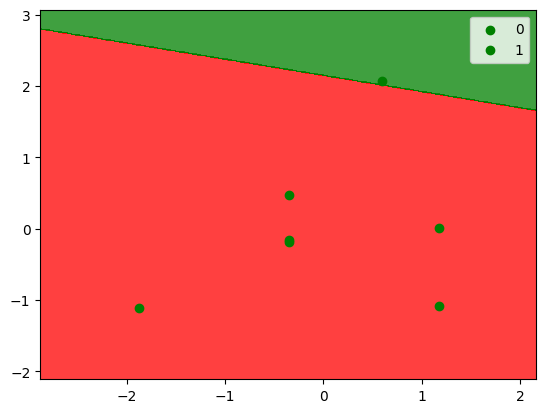

In [ ]:
from matplotlib.colors import ListedColormap
x_set,y_set=x_train,y_train
x_min,x_max=x_set[:,0].min()-1,x_set[:,0].max()+1
y_min,y_max=x_set[:,1].min()-1,x_set[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))
z=classifier.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)
plt.contourf(xx,yy,z,alpha=0.75,cmap=ListedColormap(('red','green')))
for i,j in enumerate(np.unique(y_set)):
  plt.scatter(x_set[y_set==j,0],x_set[y_set==j,1],c=ListedColormap('green','red')(i),label=j)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
data=pd.read_csv("4.csv")
data=data.drop_duplicates()
x=data.iloc[:,[0,1,3]]
y=data.iloc[:,-1]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
bias=np.mean(y_pred_train-y_train)
variance=np.var(y_pred_train)
y_pred_test=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred_test)
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
cv_score=np.mean(scores)
print(bias,variance,mse,cv_score)

0.0 30.734375 0.0 1.0


In [ ]:
import pandas as pd
df=pd.DataFrame({'team':['A','A','B','B','B','B','C','C'],
                 'points':[25,12,1,14,19,23,25,29]})
from sklearn.preprocessing import OneHotEncoder
model=OneHotEncoder(handle_unknown='ignore')
encoder_df=pd.DataFrame(model.fit_transform(df[['team']]).toarray())
final_df=df.join(encoder_df)
final_df.drop('team',axis=1,inplace=True)
final_df.columns=['points','a','b','c']
print(final_df)

   points    a    b    c
0      25  1.0  0.0  0.0
1      12  1.0  0.0  0.0
2       1  0.0  1.0  0.0
3      14  0.0  1.0  0.0
4      19  0.0  1.0  0.0
5      23  0.0  1.0  0.0
6      25  0.0  0.0  1.0
7      29  0.0  0.0  1.0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn import datasets
iris=datasets.load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[16  0  0]
 [ 0 15  2]
 [ 0  0 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.88      0.94        17
           2       0.86      1.00      0.92        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score
data={'Document': [
        'This is a document about cars',
        'Cars are a common mode of transportation',
        'The document discusses bikes',
        'Bicycles are popular for commuting',
        'Planes are used for long-distance travel',
        'The document covers trains',
        'Trains are an efficient mode of transport',
        'Car is a type of vehicle',
        'I love to drive cars',
        'Bikes are great for exercise',
        'I enjoy cycling on my bike',
        'Planes offer fast travel options',
        "I'm planning a trip by plane",
        'Trains are comfortable for long journeys',
        'Cars come in different colors',
        'I prefer red cars over blue ones',
        'Bikes have two wheels',
        'My bike needs some repairs',
        'Planes fly at high altitudes',
        "I'm afraid of flying on planes",
        'Trains have dining cars',
        'I had dinner in the train',
        'Cars consume a lot of fuel',
        "I'm considering buying a hybrid car",
        'Bikes can be customized',
        "I'm thinking of upgrading my bike",
        'Planes require thorough security checks',
        'I always arrive early for my plane flights',
        'Trains offer scenic routes',
        'I enjoy the train journey through the countryside',
        'Cars are convenient for short trips',
        'I use my car for grocery shopping',
        'Bikes promote a healthy lifestyle',
        'I cycle to work every day',
        'Planes allow international travel',
        'I flew to Europe last summer',
        'Trains reduce traffic congestion',
        'I take the train to avoid rush hour',
        'Cars need regular maintenance',
        'I schedule regular service for my car',
        'Bikes are eco-friendly',
        "I'm considering biking to reduce my carbon footprint",
        'Planes provide in-flight entertainment',
        'I watched movies during my plane journey',
        'Trains are punctual',
        'I always arrive on time with the train',
        'Cars offer freedom of mobility',
        'I love going on road trips with my car',
        'Bikes are affordable',
        'I bought my bike at a reasonable price'
    ],
    'Class': ['Car', 'Car', 'Bike', 'Bike', 'Plane', 'Train', 'Train',
              'Car', 'Car', 'Bike', 'Bike', 'Plane', 'Plane', 'Train', 'Car',
              'Car', 'Bike', 'Bike', 'Plane', 'Plane', 'Train', 'Train', 'Car',
              'Car', 'Bike', 'Bike', 'Plane', 'Plane', 'Train', 'Train', 'Car',
              'Car', 'Bike', 'Bike', 'Plane', 'Plane', 'Train', 'Train', 'Car',
              'Car', 'Bike', 'Bike', 'Plane', 'Plane', 'Train', 'Train', 'Car',
              'Car', 'Bike', 'Bike']}
df=pd.DataFrame(data)
x=df['Document']
y=df['Class']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
v=CountVectorizer()
x_train_v=v.fit_transform(x_train)
x_test_v=v.transform(x_test)
c=MultinomialNB()
c.fit(x_train_v,y_train)
y_pred=c.predict(x_test_v)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average='weighted')
reacll=recall_score(y_test,y_pred,average='weighted')
print(accuracy,precision,reacll)

0.8 0.9 0.8


In [ ]:
!pip install pgmpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.6 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylin

In [ ]:
!pip show pgmpy

Name: pgmpy
Version: 0.1.25
Summary: A library for Probabilistic Graphical Models
Home-page: https://github.com/pgmpy/pgmpy
Author: Ankur Ankan
Author-email: ankurankan@gmail.com
License: MIT
Location: /usr/local/lib/python3.10/dist-packages
Requires: joblib, networkx, numpy, opt-einsum, pandas, pyparsing, scikit-learn, scipy, statsmodels, torch, tqdm
Required-by: 


In [ ]:
import pandas as pd
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination
data=pd.read_csv("10.csv")
dataset=pd.DataFrame(data)
print(dataset)
model=BayesianNetwork([('age','Lifestyle'),
                     ('Gender','Lifestyle'),
                     ('Family','heartdisease'),
                     ('diet','cholestrol'),
                     ('Lifestyle','diet'),
                     ('cholestrol','heartdisease'),
                     ('diet','cholestrol')])
model.fit(dataset,estimator=MaximumLikelihoodEstimator)
infer=VariableElimination(model)
print('For Age enter SuperSeniorCitizen:0,SeniorCitizen:1,MiddleAged:2,Youth:3,Teen:4')
print('For Gender enter Male:0,Female:1')
print('For Family History enter Yes:1,No:0')
print('For Diet enter High:0,Medium:1')
print('For Lifestyle enter Athlete:0,Active:1,Moderate:2,Sedentary:3')
print('For Cholesterol enter High:0,BorderLine:1,Normal:2')
q=infer.query(variables=['heartdisease'],
              evidence={'age':int(input('enter age:')),
                       'Gender':int(input('enter gendeer:')),
                       'Family':int(input('enter family:')),
                       'diet':int(input('enter diet:')),
                       'Lifestyle':int(input('enter lifestyle:')),
                       'cholestrol':int(input('enter cholestrol:'))})
print(q)

    age  Gender  Family  diet  Lifestyle  cholestrol  heartdisease
0     0       0       1     1          3           0             1
1     0       1       1     1          3           0             1
2     1       0       0     0          2           1             1
3     4       0       1     1          3           2             0
4     3       1       1     0          0           2             0
5     2       0       1     1          1           0             1
6     4       0       1     0          2           0             1
7     0       0       1     1          3           0             1
8     3       1       1     0          0           2             0
9     1       1       0     0          0           2             1
10    4       1       0     1          2           0             1
11    4       0       1     1          3           2             0
12    2       1       0     0          0           0             0
13    2       0       1     1          1           0          

confusion matrix [[13 0 0] [ 0 14 1] [ 0 0 17]] what does this specify,explain the key concept

Colab AI
This is a confusion matrix, which is a table that is used to evaluate the performance of a classification model.

Each row of the matrix represents the actual class, while each column represents the predicted class. The diagonal elements of the matrix represent the number of correctly classified instances.

In this case, the matrix shows that:

13 instances were correctly classified as belonging to class 1.
14 instances were correctly classified as belonging to class 2.
17 instances were correctly classified as belonging to class 3.
1 instance was incorrectly classified as belonging to class 2, when it actually belonged to class 3.
Key concepts:

True Positives (TP): These are the instances that were correctly classified as belonging to a particular class.
True Negatives (TN): These are the instances that were correctly classified as not belonging to a particular class.
False Positives (FP): These are the instances that were incorrectly classified as belonging to a particular class.
False Negatives (FN): These are the instances that were incorrectly classified as not belonging to a particular class.
The confusion matrix can be used to calculate a number of metrics, such as accuracy, precision, recall, and F1 score.


**Precision** is the proportion of predicted positives that were actually positive.


**precision** = TP / (TP + FP)
Use code with caution
Rate this answer


Accuracy Metrics precision recall f1-score support

       0       1.00      1.00      1.00        13
       1       1.00      0.93      0.97        15
       2       0.94      1.00      0.97        17
explain this


This table shows the accuracy metrics for a classification model, broken down by class.

Precision: Out of all instances that the model predicted as belonging to a particular class, what proportion were actually of that class?
Recall: Out of all instances that actually belonged to a particular class, what proportion did the model correctly predict as belonging to that class?
F1-score: The harmonic mean of precision and recall.
In this case, the model has:

Perfect precision and recall for class 0.
High precision and recall for classes 1 and 2.
Slightly lower recall for class 1 compared to class 2.
Overall, the model is performing very well, with high precision, recall, and F1-score for all classes.



**Precision:**
For class 0, the model predicted 13 instances as belonging to class 0, and all 13 were actually class 0. This means the model has perfect precision for class 0.

For class 1, the model predicted 14 instances as belonging to class 1, and 13 of them were actually class 1. This means the model has a precision of 13/14 = 0.93 for class 1.

Similarly, the model has a precision of 16/17 = 0.94 for class 2.

**Recall:**
For class 0, the model correctly predicted 13 out of 13 class 0 instances. This means the model has perfect recall for class 0.

For class 1, the model correctly predicted 13 out of 15 class 1 instances. This means the model has a recall of 13/15 = 0.87 for class 1.

Similarly, the model has a recall of 17/17 = 1.00 for class 2.

**F1-score:**
The F1-score is the harmonic mean of precision and recall. It gives a more balanced measure of the model's performance for each class compared to just looking at precision or recall alone.

In this case, the model has a high F1-score for all classes, indicating that it is performing well at both predicting and correctly identifying instances of each class.

Overall, the model is performing very well, with high precision, recall, and F1-score for all classes.

accuracy: 0.24
confusion_matrix: [[ 0 50  0]
 [48  0  2]
 [14  0 36]]
accuracy: 0.3333333333333333
confusion_matrix: [[ 0 50  0]
 [45  0  5]
 [ 0  0 50]]


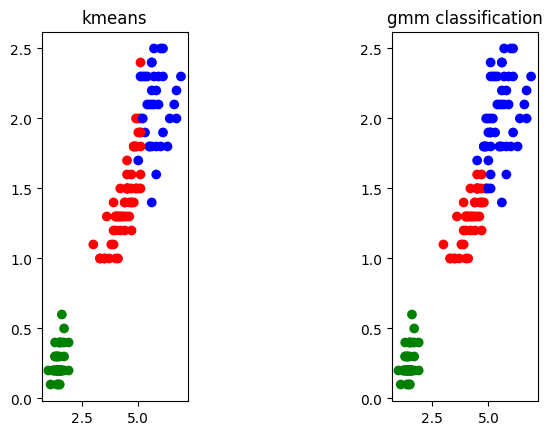

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from sklearn import datasets
iris=datasets.load_iris()
x=iris.data
y=iris.target

kmeans=KMeans(n_clusters=3,n_init=10,random_state=0)
kmeans.fit(x)
kmeans_l=kmeans.labels_
print("accuracy:",accuracy_score(y,kmeans_l))
print("confusion_matrix:",confusion_matrix(y,kmeans_l))

gmm=GaussianMixture(n_components=3,n_init=10,random_state=0)
gmm.fit(x)
gmm_l=gmm.predict(x)
print("accuracy:",accuracy_score(y,gmm_l))
print("confusion_matrix:",confusion_matrix(y,gmm_l))
colormap=['red','green','blue']

plt.subplot(1,3,1)
plt.title('kmeans')
plt.scatter(x[:,2],x[:,3],c=[colormap[label] for label in kmeans_l])

plt.subplot(1,3,3)
plt.title('gmm classification')
plt.scatter(x[:,2],x[:,3],c=[colormap[label] for label in gmm_l])
plt.show()

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import math

In [ ]:
from sklearn import datasets
data=datasets.load_diabetes()
x=data.data
y=data.target

In [ ]:
print(x)

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]
